# LeetCode #1238: Circular Permutation in Binary Representation

https://leetcode.com/problems/circular-permutation-in-binary-representation/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (BFS/backtracking)** | $O(2^n \cdot n)$ | $O(2^n)$ |
| **Gray Code with Start XOR** ★ | $O(2^n)$ | $O(2^n)$ |

---

## Understanding the Methods

### Brute Force (BFS/backtracking)
Build the sequence incrementally, always choosing the next number that differs from the previous by exactly one bit and hasn't been seen. Each step may try $O(n)$ candidates, making the total $O(2^n \cdot n)$.

### Optimal: Gray Code with Start XOR ★
The standard Gray code sequence starts at 0. XOR-ing every element with `start` rotates the sequence so it begins at `start` while preserving the single-bit-difference property between every adjacent pair (including the wrap-around). Generate $i \oplus (i >> 1) \oplus start$ for $i \in [0, 2^n)$.

**Why this is better than Brute Force:** The entire sequence is generated in $O(1)$ per element with a closed-form formula — no search, no visited set, and no backtracking.

**Constraints:**
* `1 <= n <= 16`
* `0 <= start < 2^n`

## Solutions

### C#

In [ ]:
public IList<int> CircularPermutation(int n, int start) {
    var result = new List<int>();
    // XOR each Gray code index with start to rotate the sequence to the desired origin
    for (int i = 0; i < (1 << n); i++) {
        result.Add(start ^ i ^ (i >> 1));
    }
    return result;
}

### Python

In [ ]:
def circularPermutation(self, n: int, start: int) -> list[int]:
    # XOR the Gray code of each index with start to shift the starting point
    return [start ^ i ^ (i >> 1) for i in range(1 << n)]

### Go

In [ ]:
func circularPermutation(n int, start int) []int {
    result := make([]int, 1<<n)
    // Combine the Gray code formula with an XOR offset to place start first
    for i := range result {
        result[i] = start ^ i ^ (i >> 1)
    }
    return result
}

### Rust

In [ ]:
pub fn circular_permutation(n: i32, start: i32) -> Vec<i32> {
    // XOR the standard Gray code with start to rebase the sequence
    (0..(1 << n)).map(|i| start ^ i ^ (i >> 1)).collect()
}

## Example Scenarios

**1. Common Case**
**Input:** n = 2, start = 3
Gray codes for n=2: [0,1,3,2]. XOR each with 3: [3,2,0,1]. Adjacent differences: 3⊕2=1 (one bit), 2⊕0=2 (one bit), 0⊕1=1 (one bit). Wraps: 1⊕3=2 (one bit). Valid circular permutation starting at **3**.

**2. Slightly Complex**
**Input:** n = 3, start = 5
Gray codes for n=3 XOR 5: [5,4,6,7,1,0,2,3]. Every adjacent pair including the wrap (3⊕5=6 → 1 bit set) differs by exactly 1 bit. The 8-element circular list is valid.

**3. Edge Case: Time Factor**
**Input:** n = 16, start = 0
Generates $2^{16} = 65{,}536$ codes. The XOR formula evaluates each in $O(1)$ with no search overhead. Equivalent to a plain Gray code sequence starting at 0.

**4. Edge Case: Space Factor**
**Input:** n = 1, start = 0
Only 2 elements: [0, 1]. The wrap-around 1⊕0=1 (one bit). Minimum output size of $2^n = 2$.

**5. Almost-Impossible but Plausible**
**Input:** n = 16, start = 65535 ($2^{16}-1$, all bits set)
XOR-ing all Gray codes with 65535 flips every bit — equivalent to traversing Gray code in reverse starting at the maximum value. Still a valid circular permutation with all adjacent pairs differing by exactly 1 bit.

### Infographic

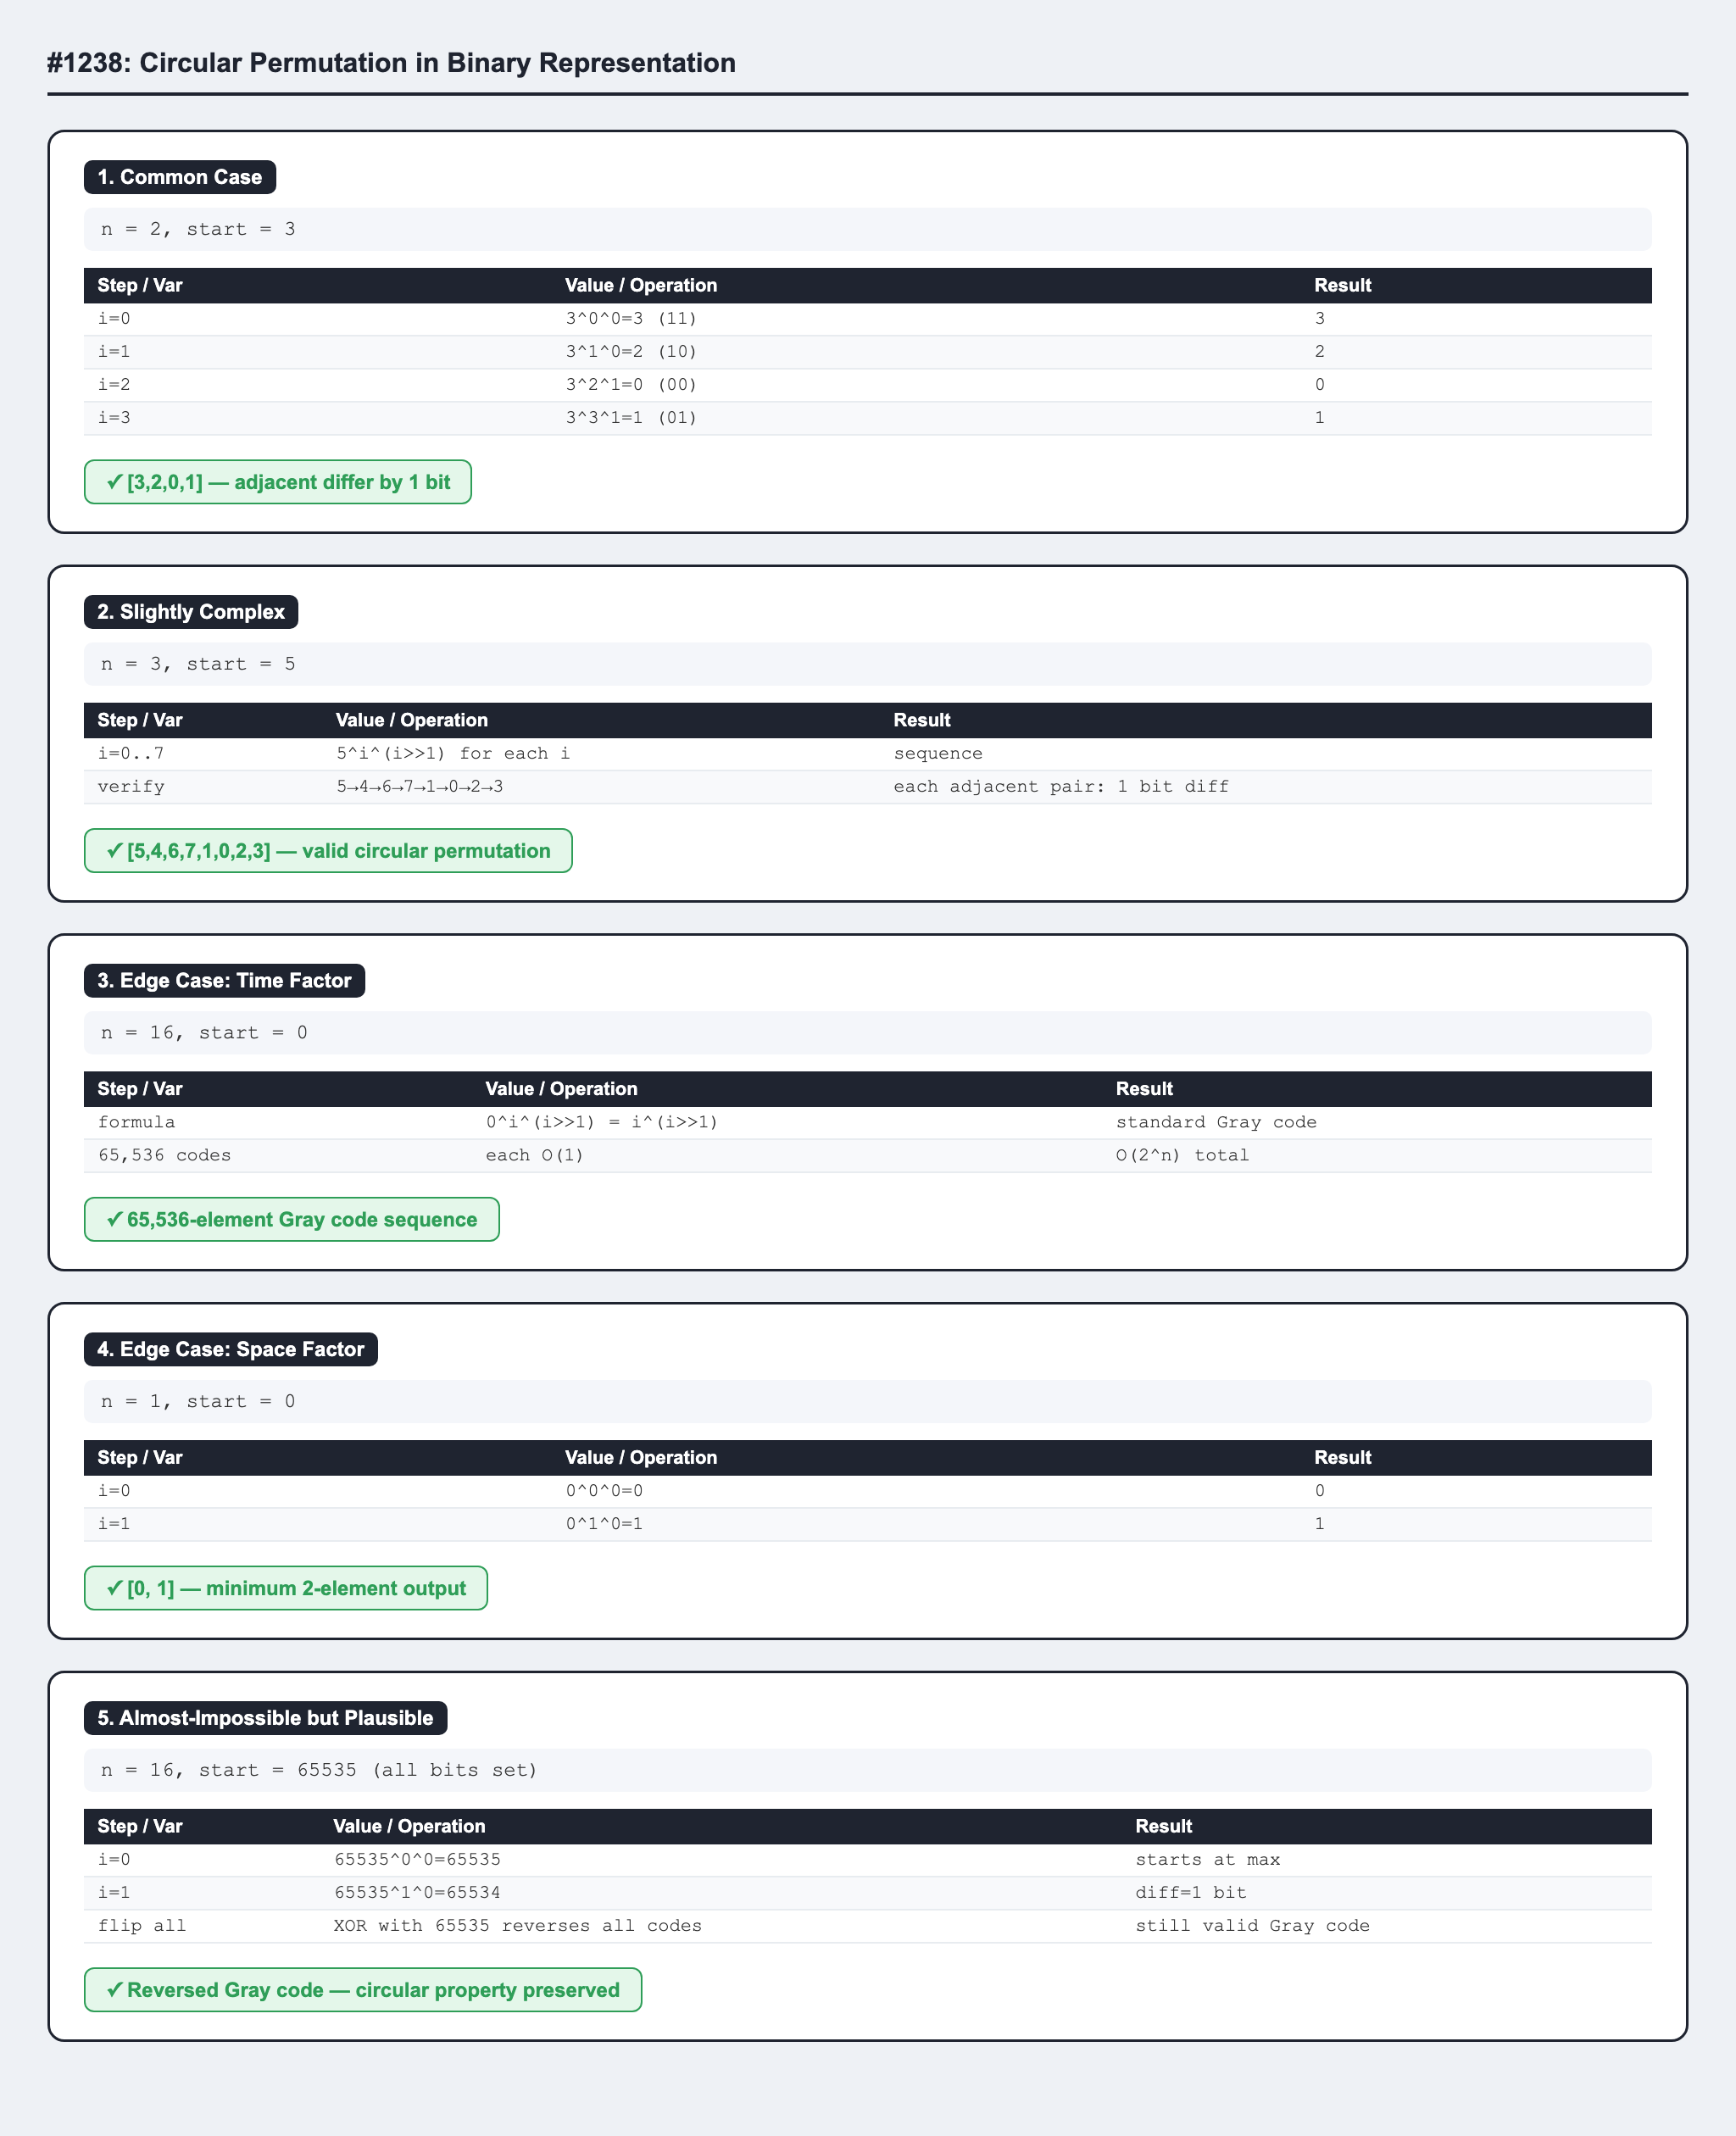